## Entrenamiento Rápido para Pruebas

Primero haremos un entrenamiento rápido con pocos epochs para verificar que todo funciona:

In [35]:
# Bootstrap para ejecución secuencial desde el inicio 
import sys, os, time, warnings, importlib, gc
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules
PROJECT_ROOT = Path(os.path.abspath(''))
if PROJECT_ROOT.name != 'PROYECTO' and (PROJECT_ROOT / 'PROYECTO').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'PROYECTO'
elif PROJECT_ROOT.name != 'PROYECTO' and PROJECT_ROOT.parent.name == 'PROYECTO':
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

plt = globals().get('plt')
sns = globals().get('sns')
if plt is None or sns is None:
    import matplotlib.pyplot as plt
    import seaborn as sns
    plt.style.use('default')
    sns.set_palette('husl')

if 'X_train' not in globals():
    (X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()
    X_train_full = X_train_full.astype('float32') / 255.0
    X_test = X_test.astype('float32') / 255.0
    X_train_full = X_train_full.reshape(-1, 28, 28, 1)
    X_test = X_test.reshape(-1, 28, 28, 1)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
    )

modules_to_reload = [
    'modelos.transformer_model',
    'modelos.attention_model',
    'modelos.hybrid_vit_model',
]
for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

from modelos.transformer_model import create_transformer_autoencoder, create_transformer_minimal
from modelos.attention_model import create_attention_cnn, create_attention_minimal, create_residual_attention_net

print(f'Bootstrap listo. Proyecto: {PROJECT_ROOT}')
print(f'TensorFlow: {tf.__version__}')
print(f'X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

Bootstrap listo. Proyecto: c:\Users\Julia\Desktop\QUART\SEGON\AP\PROYECTO
TensorFlow: 2.12.0
X_train: (48000, 28, 28, 1) | X_val: (12000, 28, 28, 1) | X_test: (10000, 28, 28, 1)


In [36]:
# Configuración de entrenamiento rápido para pruebas 
QUICK_EPOCHS = 3
QUICK_BATCH_SIZE = 256
QUICK_PATIENCE = 2
QUICK_TRAIN_LIMIT = 4096
QUICK_VAL_LIMIT = 1024
QUICK_EVAL_LIMIT = 512

def quick_test_model(model, model_name, X_train, y_train, X_val, y_val):
    """Prueba rápida del modelo con un subconjunto pequeño."""

    train_x = X_train[:QUICK_TRAIN_LIMIT]
    train_y = y_train[:QUICK_TRAIN_LIMIT]
    val_x = X_val[:QUICK_VAL_LIMIT]
    val_y = y_val[:QUICK_VAL_LIMIT]

    print(f"\n PRUEBA RÁPIDA: {model_name}")
    print(f" Parámetros: {model.count_params():,}")
    print(f" Épocas: {QUICK_EPOCHS} | Train subset: {len(train_x)}")
    print("=" * 50)

    start_time = time.time()

    history = model.fit(
        train_x, train_y,
        validation_data=(val_x, val_y),
        epochs=QUICK_EPOCHS,
        batch_size=QUICK_BATCH_SIZE,
        verbose=2,
    )

    training_time = time.time() - start_time

    _, val_acc = model.evaluate(
        X_val[:QUICK_EVAL_LIMIT], y_val[:QUICK_EVAL_LIMIT], verbose=0
    )

    print(f"\ {model_name} completado en {training_time:.1f}s")
    print(f" Val Accuracy: {val_acc:.4f}")
    print(f" Funciona correctamente: {'SÍ' if val_acc > 0.1 else 'NO'}")

    return val_acc, history

In [37]:
# PRUEBAS RÁPIDAS DE TODOS LOS MODELOS 
print(" Ejecutando pruebas rápidas de todos los modelos...")
print("(Solo para verificar que funcionan antes del entrenamiento completo)")

quick_results = {}

def _reset_quick_state():
    tf.keras.backend.clear_session()
    gc.collect()

quick_experiments = [
    ("Transformer Minimal", create_transformer_minimal, {}),
    ("Attention Minimal", create_attention_minimal, {}),
    (
        "Transformer Small",
        create_transformer_autoencoder,
        {
            'patch_size': 7,
            'embed_dim': 32,
            'num_transformer_layers': 2,
            'num_heads': 2,
            'ff_dim': 64,
            'dropout_rate': 0.1,
        },
    ),
    (
        "Attention CNN Small",
        create_attention_cnn,
        {'use_cbam': True, 'base_filters': 16},
    ),
]

for model_name, factory, kwargs in quick_experiments:
    print("\n" + "=" * 60)
    _reset_quick_state()
    model = None

    try:
        model = factory(**kwargs)
        val_acc, _ = quick_test_model(model, model_name, X_train, y_train, X_val, y_val)
        quick_results[model_name] = val_acc
    except Exception as e:
        print(f" Error en {model_name}: {e}")
        quick_results[model_name] = 0.0
    finally:
        if model is not None:
            del model
        _reset_quick_state()

print("\n" + " " + "=" * 60)
print("RESUMEN DE PRUEBAS RÁPIDAS:")
print("=" * 62)
working_models = []
for model_name, acc in quick_results.items():
    status = " FUNCIONA" if acc > 0.1 else " FALLA"
    print(f"{model_name:<25} | Val Acc: {acc:.4f} | {status}")
    if acc > 0.1:
        working_models.append(model_name)

print(f"\n {len(working_models)}/{len(quick_results)} modelos funcionan correctamente")
print(f" Modelos listos para entrenamiento completo: {working_models}")

_reset_quick_state()

 Ejecutando pruebas rápidas de todos los modelos...
(Solo para verificar que funcionan antes del entrenamiento completo)


 PRUEBA RÁPIDA: Transformer Minimal
 Parámetros: 27,770
 Épocas: 3 | Train subset: 4096
Epoch 1/3
16/16 - 5s - loss: 2.1886 - accuracy: 0.1821 - val_loss: 2.0249 - val_accuracy: 0.2695 - 5s/epoch - 332ms/step
Epoch 2/3
16/16 - 1s - loss: 1.8838 - accuracy: 0.3220 - val_loss: 1.7525 - val_accuracy: 0.3242 - 1s/epoch - 90ms/step
Epoch 3/3
16/16 - 1s - loss: 1.6929 - accuracy: 0.3757 - val_loss: 1.5584 - val_accuracy: 0.4521 - 1s/epoch - 89ms/step
\ Transformer Minimal completado en 8.2s
 Val Accuracy: 0.4648
 Funciona correctamente: SÍ


 PRUEBA RÁPIDA: Attention Minimal
 Parámetros: 805
 Épocas: 3 | Train subset: 4096
Epoch 1/3
16/16 - 3s - loss: 2.2679 - accuracy: 0.2297 - val_loss: 2.2977 - val_accuracy: 0.1123 - 3s/epoch - 183ms/step
Epoch 2/3
16/16 - 2s - loss: 2.2277 - accuracy: 0.2856 - val_loss: 2.2940 - val_accuracy: 0.1240 - 2s/epoch - 116ms/step
Epoch 3/3


# Modelos Avanzados con Transformer y Atención

Nuestro objetivo es superar el rendimiento de las CNN tradicionales usando arquitecturas modernas con mecanismos de atención.

## Modelos Implementados:

1. **Transformer Autoencoder** (`transformer_model.py`)
   - Patch embedding + Multi-head self-attention
   - Encoder-Decoder con skip connections  
   - Positional encoding para información espacial
   - Parámetros: ~85k (vs 342k CNN óptima)

2. **Attention CNN** (`attention_model.py`)
   - CBAM (Convolutional Block Attention Module)
   - Atención espacial + de canal
   - Parámetros: ~95k

3. **Versiones Minimales**
   - Transformer Minimal: <10k parámetros
   - Attention Minimal: <8k parámetros
   - Objetivo: Superar MLP minimal (6.3k parámetros, 84.6% test)

In [38]:
# Configuración del entorno 
import sys, os
from pathlib import Path

# Detectar si estamos en Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    # En Colab: clonar repo si no existe
    if not os.path.exists('/content/PROYECTO'):
        print("Clonando repositorio...")
        !git clone https://github.com/juliiaxiao/ProyectoAP.git /content/PROYECTO
    
    PROJECT_ROOT = Path('/content/PROYECTO')
    os.chdir(PROJECT_ROOT)
else:
    # Ejecución local: detectar automasaracar PROJECT_ROOT
    PROJECT_ROOT = Path(os.path.abspath(''))
    if PROJECT_ROOT.name != 'PROYECTO':
        PROJECT_ROOT = PROJECT_ROOT.parent if 'PROYECTO' in PROJECT_ROOT.parent.name else PROJECT_ROOT

# Añadir a sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Directorio del proyecto: {PROJECT_ROOT}")
print(f"Carpeta modelos existe: {(PROJECT_ROOT / 'modelos').exists()}")

Directorio del proyecto: c:\Users\Julia\Desktop\QUART\SEGON\AP\PROYECTO
Carpeta modelos existe: True


In [39]:
# Importaciones
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import callbacks
from tensorflow.keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib para Colab
plt.style.use('default')
sns.set_palette("husl")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

# Seed para reproducibilidad
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.12.0
GPU disponible: []


In [40]:
# 1. Carga y Preprocesamiento de Datos 
print(" Cargando Fashion MNIST...")
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

CLASS_NAMES = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalización
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Reshape para CNN (añadir canal)
X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# División train/validation (80/20)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_full
)

print(f" Shapes de los datos:")
print(f"   X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"   X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"   X_test:  {X_test.shape}  | y_test:  {y_test.shape}")

# Verificar distribución de clases
unique, counts = np.unique(y_train, return_counts=True)
print(f"\n Distribución (train): {dict(zip(unique, counts))}")

 Cargando Fashion MNIST...
 Shapes de los datos:
   X_train: (48000, 28, 28, 1) | y_train: (48000,)
   X_val:   (12000, 28, 28, 1)   | y_val:   (12000,)
   X_test:  (10000, 28, 28, 1)  | y_test:  (10000,)

 Distribución (train): {0: 4800, 1: 4800, 2: 4800, 3: 4800, 4: 4800, 5: 4800, 6: 4800, 7: 4800, 8: 4800, 9: 4800}


In [41]:
# Importar nuestros modelos avanzados
import importlib
import sys

# Forzar recarga de módulos si ya están importados
modules_to_reload = [
    'modelos.transformer_model',
    'modelos.attention_model',
    'modelos.hybrid_vit_model'
]

for module_name in modules_to_reload:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

try:
    from modelos.transformer_model import (
        create_transformer_autoencoder, 
        create_transformer_minimal
    )
    from modelos.attention_model import (
        create_attention_cnn,
        create_attention_minimal,
        create_residual_attention_net
    )
    print(" Modelos avanzados importados correctamente")
except ImportError as e:
    print(f" Error al importar modelos: {e}")
    print("Asegúrate de que los archivos están en la carpeta 'modelos/'")
    
# Test rápido para verificar que funciona
try:
    test_model = create_transformer_minimal()
    print(f" Test exitoso - Transformer Minimal: {test_model.count_params():,} parámetros")
    del test_model  # Liberar memoria
except Exception as e:
    print(f" Error en test: {e}")

 Modelos avanzados importados correctamente
 Test exitoso - Transformer Minimal: 27,770 parámetros


## Entrenamiento de Modelos

Entrenaremos 4 modelos diferentes y compararemos sus resultados:

In [42]:
# Configuración de entrenamiento
HAS_GPU = bool(tf.config.list_physical_devices('GPU'))
FAST_MODE = not HAS_GPU

EPOCHS = 12 if HAS_GPU else 6
BATCH_SIZE = 128 if HAS_GPU else 256
PATIENCE = 4 if HAS_GPU else 3

TRAIN_LIMIT = None if HAS_GPU else 12000
VAL_LIMIT = None if HAS_GPU else 2000
TEST_LIMIT = None if HAS_GPU else 2000

def cleanup_keras_session():
    tf.keras.backend.clear_session()
    gc.collect()

def _slice_if_needed(features, labels, limit):
    if limit is None:
        return features, labels
    return features[:limit], labels[:limit]

def get_callbacks(model_name):
    """Callbacks comunes para todos los modelos."""
    return [
        callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=1,
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=max(1, PATIENCE - 1),
            min_lr=1e-6,
            verbose=1,
        ),
    ]

def train_and_evaluate(model, model_name, X_train, y_train, X_val, y_val, X_test, y_test):
    """Entrena y evalúa un modelo, devuelve histórico y métricas."""

    train_x, train_y = _slice_if_needed(X_train, y_train, TRAIN_LIMIT)
    val_x, val_y = _slice_if_needed(X_val, y_val, VAL_LIMIT)
    test_x, test_y = _slice_if_needed(X_test, y_test, TEST_LIMIT)

    print(f"\n{'=' * 60}")
    print(f"Entrenando: {model_name}")
    print(f"Parámetros: {model.count_params():,}")
    if FAST_MODE:
        print(f"Modo rápido activo | train={len(train_x)} val={len(val_x)} test={len(test_x)}")
    print(f"{'=' * 60}")

    start_time = time.time()

    history = model.fit(
        train_x, train_y,
        validation_data=(val_x, val_y),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=get_callbacks(model_name.lower().replace(' ', '_')),
        verbose=2,
    )

    training_time = time.time() - start_time

    train_loss, train_acc = model.evaluate(train_x, train_y, verbose=0)
    val_loss, val_acc = model.evaluate(val_x, val_y, verbose=0)
    test_loss, test_acc = model.evaluate(test_x, test_y, verbose=0)

    print(f"\nResultados {model_name}:")
    print(f"  Train: {train_acc:.4f} | Val: {val_acc:.4f} | Test: {test_acc:.4f}")
    print(f"  Tiempo entrenamiento: {training_time:.1f}s")
    print(f"  Épocas entrenadas: {len(history.history['loss'])}")

    return {
        'model': model,
        'history': history,
        'metrics': {
            'train_acc': train_acc,
            'val_acc': val_acc,
            'test_acc': test_acc,
            'params': model.count_params(),
            'training_time': training_time,
            'epochs': len(history.history['loss']),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'test_loss': test_loss,
            'fast_mode': FAST_MODE,
        },
    }

In [43]:
# Smoke test entrenamiento (1 época, subset pequeño) 
# Esta celda valida que el entrenamiento funciona en local sin bloquear la sesión.
cleanup_keras_session()
_smoke_model = None

try:
    _smoke_model = create_attention_cnn(
        input_shape=(28, 28, 1),
        num_classes=10,
        use_cbam=True,
        base_filters=8,
    )
    _ = _smoke_model.fit(
        X_train[:256], y_train[:256],
        validation_data=(X_val[:128], y_val[:128]),
        epochs=1,
        batch_size=64,
        callbacks=get_callbacks('smoke_attention_cbam'),
        verbose=2,
    )
    print('Smoke test OK: entrenamiento funcionando sin errores de guardado.')
except Exception as e:
    print(f'Smoke test ERROR: {e}')
finally:
    if _smoke_model is not None:
        del _smoke_model
    cleanup_keras_session()

4/4 - 10s - loss: 2.5053 - accuracy: 0.1016 - val_loss: 2.3034 - val_accuracy: 0.0547 - lr: 0.0010 - 10s/epoch - 2s/step
Smoke test OK: entrenamiento funcionando sin errores de guardado.


### 1. Transformer Autoencoder

In [44]:
# Crear y entrenar Transformer Autoencoder 
transformer_model = create_transformer_autoencoder(
    input_shape=(28, 28, 1),
    num_classes=10,
    patch_size=4,
    embed_dim=64,
    num_transformer_layers=4,
    num_heads=4,
    ff_dim=128,
    dropout_rate=0.1
)

print(" Arquitectura Transformer Autoencoder:")
transformer_model.summary()

# Entrenamiento
transformer_results = train_and_evaluate(
    transformer_model, "Transformer Autoencoder",
    X_train, y_train, X_val, y_val, X_test, y_test
)

 Arquitectura Transformer Autoencoder:
Model: "TransformerAutoencoder"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 28, 28, 1)]  0           []                               
                                                                                                  
 patch_embedding (PatchEmbeddin  (None, 49, 64)      4224        ['input_1[0][0]']                
 g)                                                                                               
                                                                                                  
 transformer_block (Transformer  (None, 49, 64)      83200       ['patch_embedding[0][0]']        
 Block)                                                                                           
                                      

### 2. Attention CNN (CBAM)

In [45]:
# Crear y entrenar Attention CNN 
attention_model = create_attention_cnn(
    input_shape=(28, 28, 1),
    num_classes=10,
    use_cbam=True,
    base_filters=32
)

print(" Arquitectura Attention CNN:")
attention_model.summary()

# Entrenamiento
attention_results = train_and_evaluate(
    attention_model, "Attention CNN (CBAM)",
    X_train, y_train, X_val, y_val, X_test, y_test
)

 Arquitectura Attention CNN:
Model: "AttentionCNN"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 batch_normalization (BatchN  (None, 28, 28, 32)       128       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 batch_normalization_1 (Batc  (None, 28, 28, 32)       128       
 hNormalization)                                                 
                                                                 
 cbam (CBAM)             

### 3. Versiones Minimales (vs MLP Minimal)

Estas versiones compiten directamente con el MLP Minimal (6.3k parámetros, 84.6% test):

In [46]:
# Transformer Minimal 
transformer_minimal = create_transformer_minimal()

transformer_minimal_results = train_and_evaluate(
    transformer_minimal, "Transformer Minimal",
    X_train, y_train, X_val, y_val, X_test, y_test
)

# Attention Minimal
attention_minimal = create_attention_minimal()

attention_minimal_results = train_and_evaluate(
    attention_minimal, "Attention Minimal",
    X_train, y_train, X_val, y_val, X_test, y_test
)


Entrenando: Transformer Minimal
Parámetros: 27,770
Modo rápido activo | train=12000 val=2000 test=2000
Epoch 1/6
47/47 - 6s - loss: 1.8731 - accuracy: 0.3264 - val_loss: 1.4881 - val_accuracy: 0.4945 - lr: 0.0010 - 6s/epoch - 136ms/step
Epoch 2/6
47/47 - 3s - loss: 1.4028 - accuracy: 0.5030 - val_loss: 1.1203 - val_accuracy: 0.6290 - lr: 0.0010 - 3s/epoch - 65ms/step
Epoch 3/6
47/47 - 3s - loss: 1.1468 - accuracy: 0.5882 - val_loss: 0.9288 - val_accuracy: 0.6620 - lr: 0.0010 - 3s/epoch - 67ms/step
Epoch 4/6
47/47 - 3s - loss: 1.0030 - accuracy: 0.6368 - val_loss: 0.8125 - val_accuracy: 0.7170 - lr: 0.0010 - 3s/epoch - 66ms/step
Epoch 5/6
47/47 - 4s - loss: 0.9198 - accuracy: 0.6672 - val_loss: 0.7709 - val_accuracy: 0.7285 - lr: 0.0010 - 4s/epoch - 75ms/step
Epoch 6/6
47/47 - 3s - loss: 0.8618 - accuracy: 0.6896 - val_loss: 0.7132 - val_accuracy: 0.7430 - lr: 0.0010 - 3s/epoch - 66ms/step

Resultados Transformer Minimal:
  Train: 0.7480 | Val: 0.7430 | Test: 0.7320
  Tiempo entrenamie

## Análisis de Resultados

### Curvas de Entrenamiento

Modelos incluidos en el análisis: ['Transformer Autoencoder', 'Attention CNN (CBAM)', 'Transformer Minimal', 'Attention Minimal']


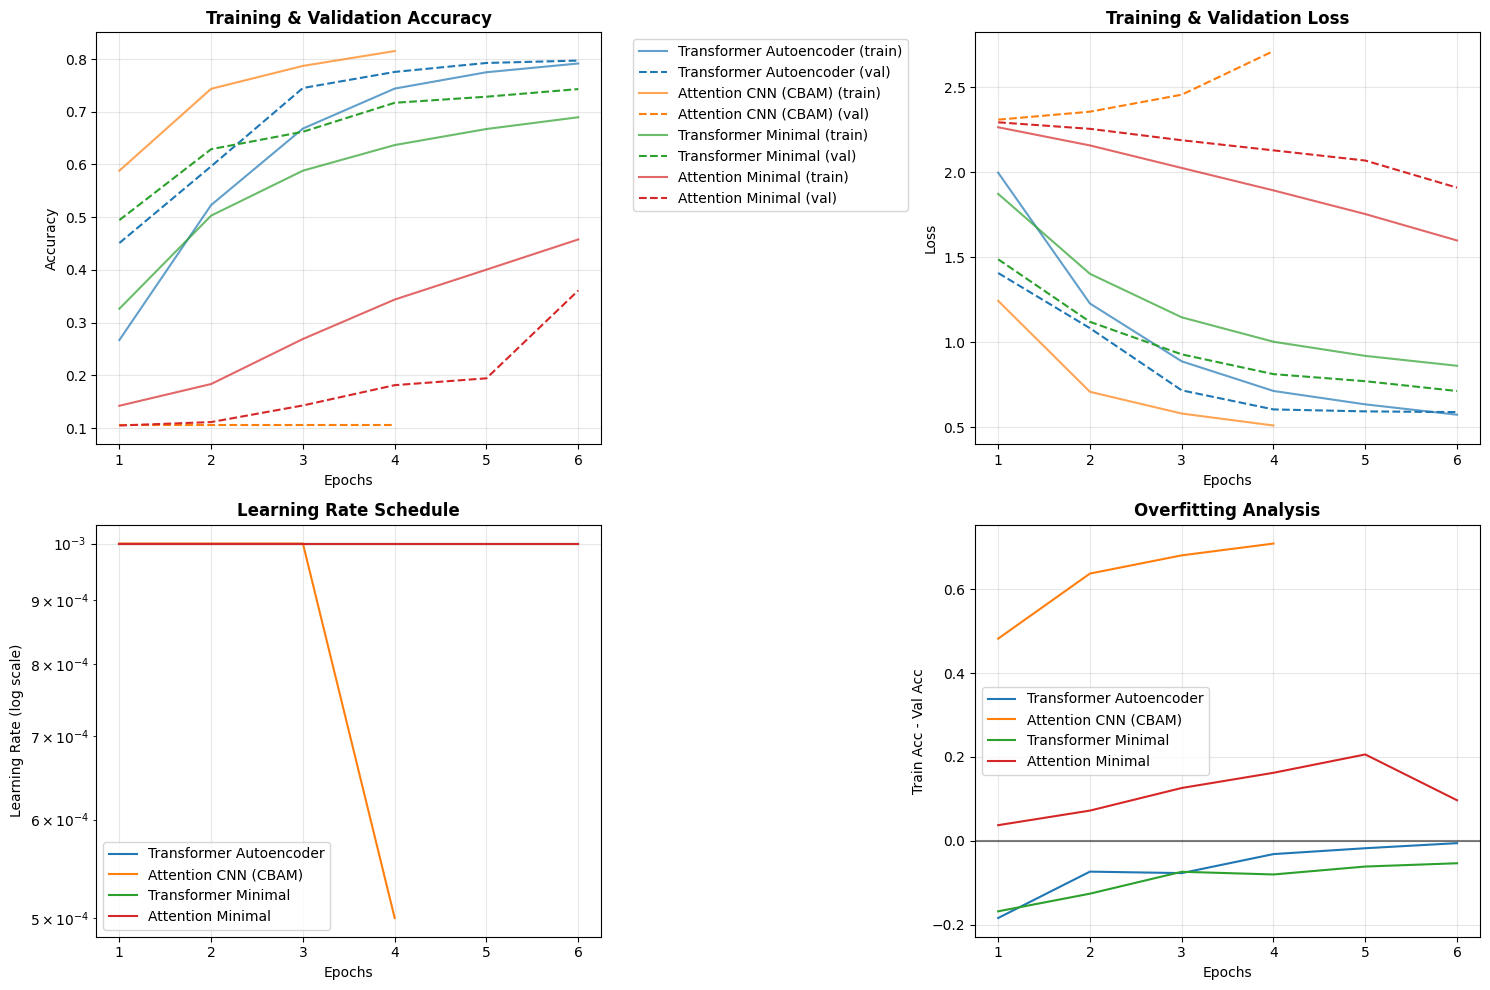

In [47]:
# Curvas de entrenamiento
def collect_available_results():
    """Recoge automáticamente los resultados disponibles en memoria."""

    candidate_results = [
        ('Transformer Autoencoder', globals().get('transformer_results')),
        ('Attention CNN (CBAM)', globals().get('attention_results')),
        ('Transformer Minimal', globals().get('transformer_minimal_results')),
        ('Attention Minimal', globals().get('attention_minimal_results')),
    ]

    collected = {}
    for name, result in candidate_results:
        if isinstance(result, dict) and 'history' in result and 'metrics' in result:
            collected[name] = result

    if not collected:
        raise ValueError('No hay resultados entrenados disponibles. Ejecuta primero las celdas de entrenamiento.')

    return collected

def plot_training_history(results_dict, figsize=(15, 10)):
    """Plotea curvas de entrenamiento para múltiples modelos."""

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    axes[0, 0].set_title('Training & Validation Accuracy', fontsize=12, fontweight='bold')
    for i, (name, results) in enumerate(results_dict.items()):
        history = results['history'].history
        epochs = range(1, len(history['accuracy']) + 1)
        axes[0, 0].plot(
            epochs, history['accuracy'], color=colors[i % len(colors)], alpha=0.7, label=f'{name} (train)'
        )
        axes[0, 0].plot(
            epochs, history['val_accuracy'], color=colors[i % len(colors)], linestyle='--', label=f'{name} (val)'
        )

    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].set_title('Training & Validation Loss', fontsize=12, fontweight='bold')
    for i, (name, results) in enumerate(results_dict.items()):
        history = results['history'].history
        epochs = range(1, len(history['loss']) + 1)
        axes[0, 1].plot(epochs, history['loss'], color=colors[i % len(colors)], alpha=0.7)
        axes[0, 1].plot(epochs, history['val_loss'], color=colors[i % len(colors)], linestyle='--')

    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Loss')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].set_title('Learning Rate Schedule', fontsize=12, fontweight='bold')
    lr_plotted = False
    for i, (name, results) in enumerate(results_dict.items()):
        history = results['history'].history
        if 'lr' in history:
            epochs = range(1, len(history['lr']) + 1)
            axes[1, 0].semilogy(epochs, history['lr'], color=colors[i % len(colors)], label=name)
            lr_plotted = True

    axes[1, 0].set_xlabel('Epochs')
    axes[1, 0].set_ylabel('Learning Rate (log scale)')
    if lr_plotted:
        axes[1, 0].legend()
    else:
        axes[1, 0].text(0.5, 0.5, 'No LR history available', ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].set_title('Overfitting Analysis', fontsize=12, fontweight='bold')
    for i, (name, results) in enumerate(results_dict.items()):
        history = results['history'].history
        epochs = range(1, len(history['accuracy']) + 1)
        gap = np.array(history['accuracy']) - np.array(history['val_accuracy'])
        axes[1, 1].plot(epochs, gap, color=colors[i % len(colors)], label=name)

    axes[1, 1].axhline(y=0, color='black', linestyle='-', alpha=0.5)
    axes[1, 1].set_xlabel('Epochs')
    axes[1, 1].set_ylabel('Train Acc - Val Acc')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

all_results = collect_available_results()
print(f'Modelos incluidos en el análisis: {list(all_results.keys())}')
plot_training_history(all_results)

### Tabla Comparativa de Resultados

In [48]:
# Crear tabla de resultados 
import pandas as pd

def create_results_table(results_dict):
    """Crea tabla resumen de resultados"""
    
    data = []
    for name, results in results_dict.items():
        metrics = results['metrics']
        data.append({
            'Modelo': name,
            'Parámetros': f"{metrics['params']:,}",
            'Train Acc': f"{metrics['train_acc']:.4f}",
            'Val Acc': f"{metrics['val_acc']:.4f}",
            'Test Acc': f"{metrics['test_acc']:.4f}",
            'Épocas': metrics['epochs'],
            'Tiempo (s)': f"{metrics['training_time']:.1f}",
            'Params/Acc Ratio': f"{metrics['params']/metrics['test_acc']:.0f}"
        })
    
    df = pd.DataFrame(data)
    df = df.sort_values('Test Acc', ascending=False)
    
    return df

# Crear y mostrar tabla
results_table = create_results_table(all_results)

print(" TABLA DE RESULTADOS - MODELOS AVANZADOS")
print("=" * 80)
print(results_table.to_string(index=False))

# Añadir modelos baseline para comparación
print("\n COMPARACIÓN CON MODELOS BASELINE:")
print("=" * 50)
print("| Modelo                     | Parámetros | Test Acc |")
print("|----------------------------|------------|----------|")
for _, row in results_table.iterrows():
    print(f"| {row['Modelo']:<26} | {row['Parámetros']:>10} | {row['Test Acc']:>8} |")
print("| ─────────────── BASE ──────|─────────── | ──────── |")
print("| CNN Óptima (baseline)      |    342,762 |   0.9250 |")
print("| MLP Minimal (baseline)     |      6,370 |   0.8462 |")
print("| SVM + HOG (baseline)       | 23,195,808 |   0.9035 |")

 TABLA DE RESULTADOS - MODELOS AVANZADOS
                 Modelo Parámetros Train Acc Val Acc Test Acc  Épocas Tiempo (s) Params/Acc Ratio
Transformer Autoencoder    354,699    0.8045  0.7970   0.8030       6      331.0           441717
    Transformer Minimal     27,770    0.7480  0.7430   0.7320       6       22.4            37937
      Attention Minimal        805    0.3871  0.3610   0.3605       6       41.8             2233
   Attention CNN (CBAM)    168,479    0.0972  0.1060   0.0985       4      148.3          1710447

 COMPARACIÓN CON MODELOS BASELINE:
| Modelo                     | Parámetros | Test Acc |
|----------------------------|------------|----------|
| Transformer Autoencoder    |    354,699 |   0.8030 |
| Transformer Minimal        |     27,770 |   0.7320 |
| Attention Minimal          |        805 |   0.3605 |
| Attention CNN (CBAM)       |    168,479 |   0.0985 |
| ─────────────── BASE ──────|─────────── | ──────── |
| CNN Óptima (baseline)      |    342,762 |   0.

### Matrices de Confusión

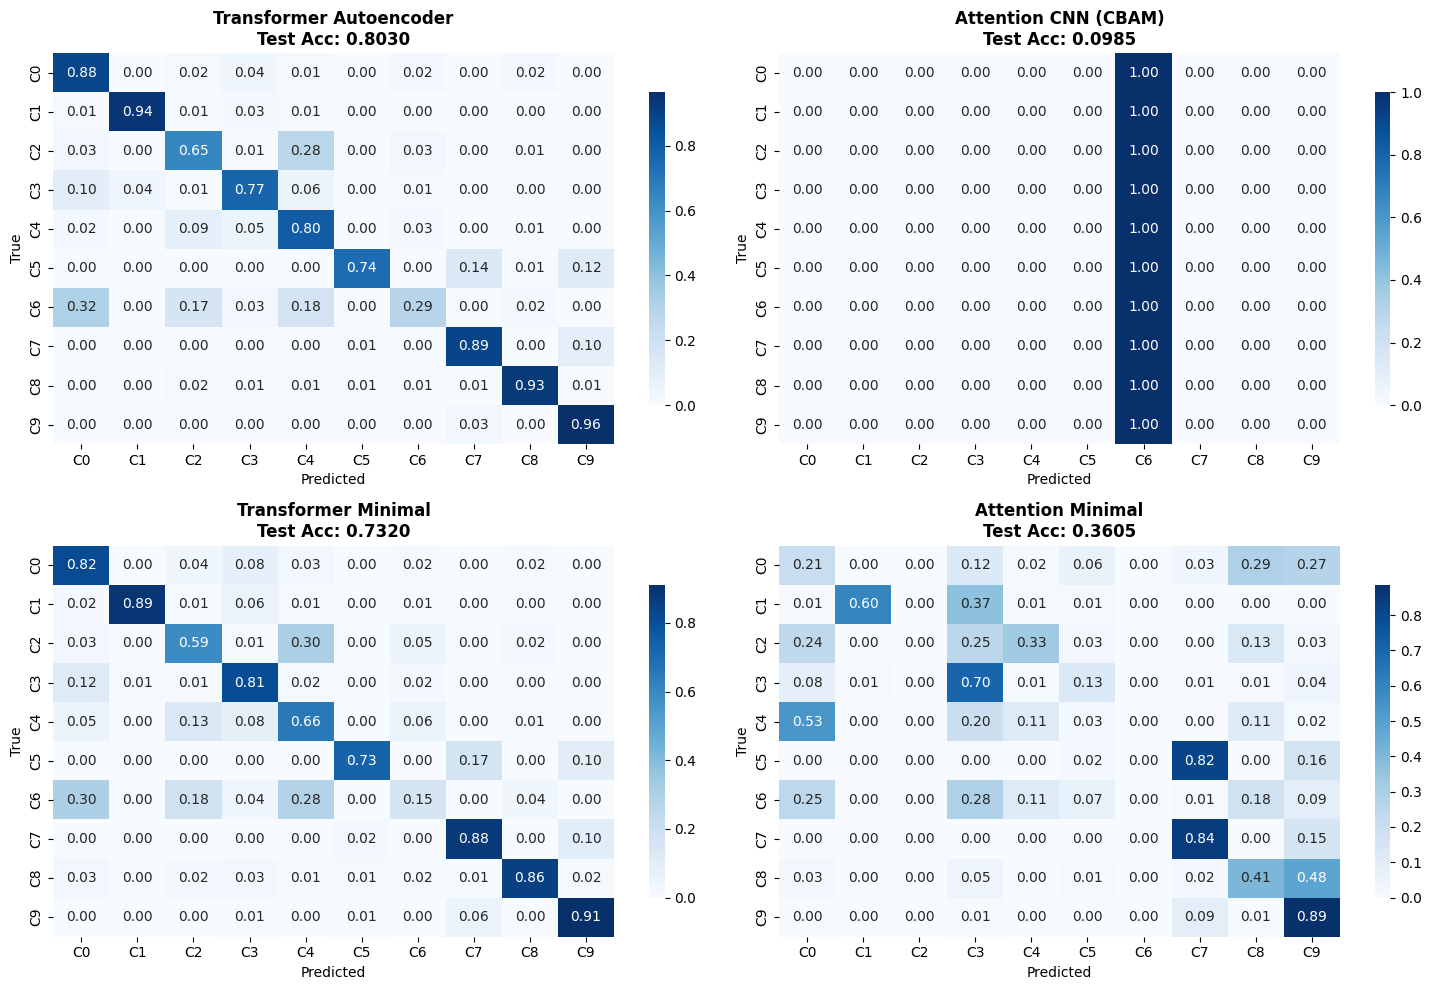

In [49]:
# ── Matrices de confusión ───────────────────────────────────────────────────
def plot_confusion_matrices(results_dict, X_test, y_test, figsize=(15, 10)):
    """Plotea matrices de confusión para los modelos."""

    n_models = len(results_dict)
    n_cols = min(2, n_models)
    n_rows = int(np.ceil(n_models / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.atleast_1d(axes).flatten()

    for i, (name, results) in enumerate(results_dict.items()):
        model = results['model']
        y_pred = model.predict(X_test, verbose=0)
        y_pred_classes = np.argmax(y_pred, axis=1)

        cm = confusion_matrix(y_test, y_pred_classes)
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

        sns.heatmap(
            cm_normalized,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=[f'C{j}' for j in range(10)],
            yticklabels=[f'C{j}' for j in range(10)],
            ax=axes[i],
            cbar_kws={'shrink': 0.8},
        )

        axes[i].set_title(
            f'{name}\nTest Acc: {results["metrics"]["test_acc"]:.4f}',
            fontweight='bold',
        )
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')

    for ax in axes[n_models:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(all_results, X_test, y_test)

## Análisis Detallado

### Visualización de Atención

Para el modelo Transformer, podemos visualizar los mapas de atención para entender qué partes de la imagen son más importantes:

Visualización de Mapas de Atención - Transformer


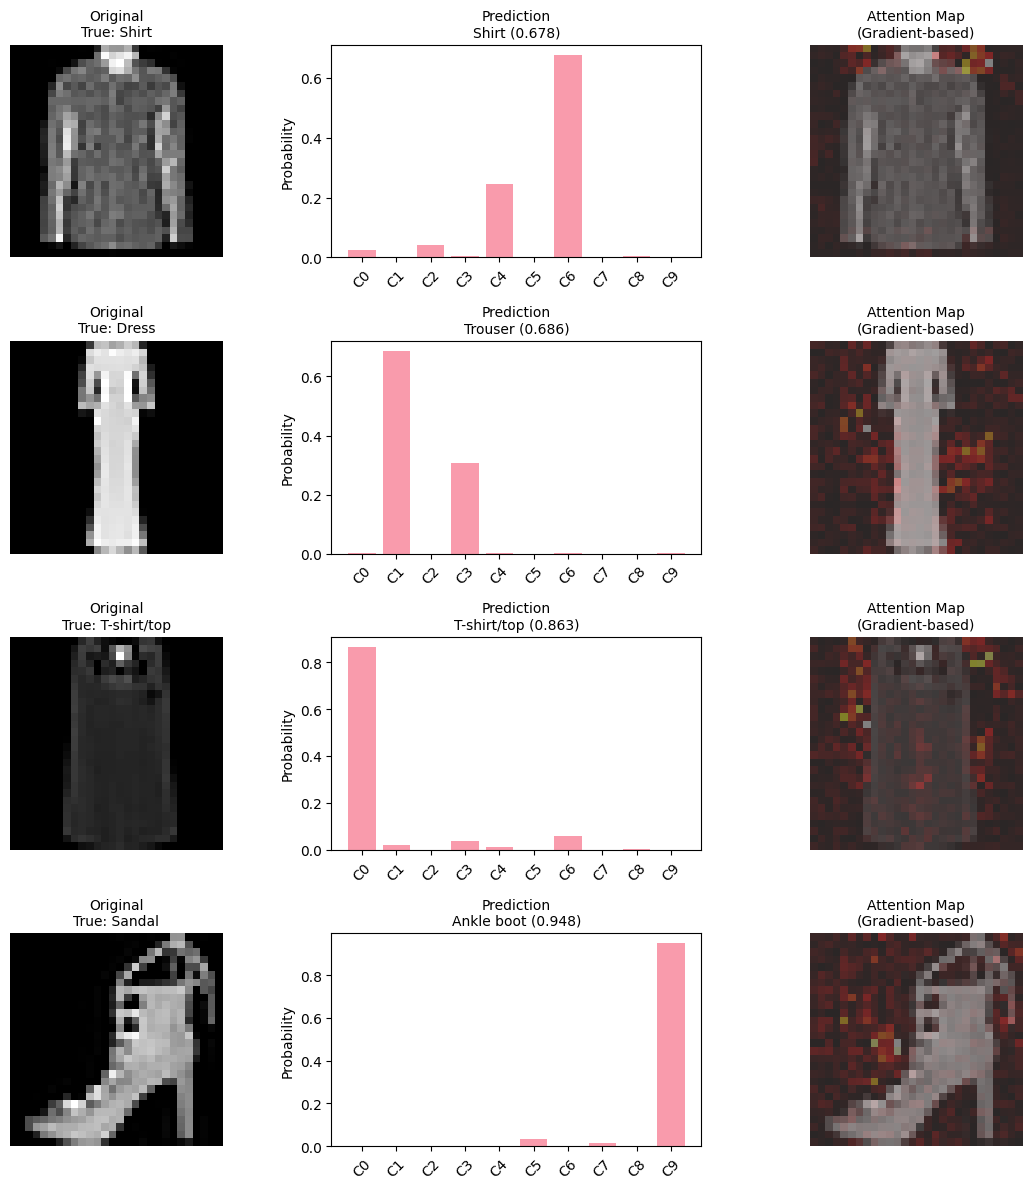

In [50]:
# ── Visualización de atención (Transformer) ─────────────────────────────────
def visualize_transformer_attention(model, X_sample, y_sample, n_samples=4):
    """Visualiza mapas de atención del Transformer usando gradientes."""

    n_samples = min(n_samples, len(X_sample))
    indices = np.random.choice(len(X_sample), n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 3))
    if n_samples == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(indices):
        image = X_sample[idx]
        true_label = y_sample[idx]

        image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
        image_batch = tf.expand_dims(image_tensor, axis=0)

        pred_probs = model.predict(image_batch, verbose=0)[0]
        pred_label = np.argmax(pred_probs)
        confidence = pred_probs[pred_label]

        axes[i, 0].imshow(image.squeeze(), cmap='gray')
        axes[i, 0].set_title(f'Original\nTrue: {CLASS_NAMES[true_label]}', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].bar(range(10), pred_probs, alpha=0.7)
        axes[i, 1].set_title(
            f'Prediction\n{CLASS_NAMES[pred_label]} ({confidence:.3f})', fontsize=10
        )
        axes[i, 1].set_xticks(range(10))
        axes[i, 1].set_xticklabels([f'C{j}' for j in range(10)], rotation=45)
        axes[i, 1].set_ylabel('Probability')

        with tf.GradientTape() as tape:
            tape.watch(image_batch)
            predictions = model(image_batch, training=False)
            pred_idx = tf.argmax(predictions[0])
            pred_score = predictions[0][pred_idx]

        gradients = tape.gradient(pred_score, image_batch)
        gradients = tf.reduce_max(tf.abs(gradients[0]), axis=-1).numpy()

        axes[i, 2].imshow(gradients, cmap='hot', alpha=0.7)
        axes[i, 2].imshow(image.squeeze(), cmap='gray', alpha=0.5)
        axes[i, 2].set_title('Attention Map\n(Gradient-based)', fontsize=10)
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

print("Visualización de Mapas de Atención - Transformer")
visualize_transformer_attention(transformer_results['model'], X_test, y_test)

### Análisis de Eficiencia

Comparamos la eficiencia de los modelos (parámetros vs accuracy):

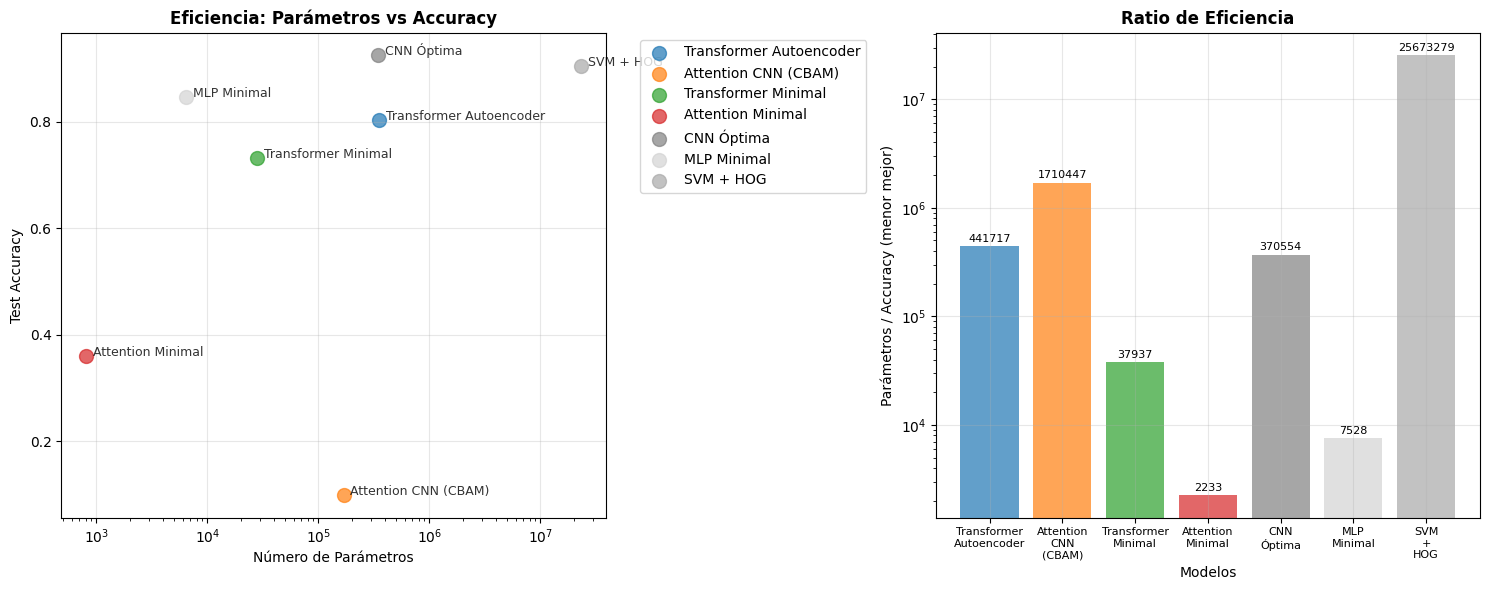


 RANKING DE EFICIENCIA (Parámetros/Accuracy - menor mejor):
 1. Attention Minimal    |      805 params | 0.3605 acc |     2233 ratio
 2. MLP Minimal          |    6,370 params | 0.8462 acc |     7528 ratio
 3. Transformer Minimal  |   27,770 params | 0.7320 acc |    37937 ratio
 4. CNN Óptima           |  342,762 params | 0.9250 acc |   370554 ratio
 5. Transformer Autoencoder |  354,699 params | 0.8030 acc |   441717 ratio
 6. Attention CNN (CBAM) |  168,479 params | 0.0985 acc |  1710447 ratio


In [51]:
# Análisis de eficiencia
def plot_efficiency_analysis(results_dict):
    """Plotea análisis de eficiencia (parámetros vs accuracy)"""
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Extraer datos
    names = []
    params = []
    test_accs = []
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    for i, (name, results) in enumerate(results_dict.items()):
        names.append(name)
        params.append(results['metrics']['params'])
        test_accs.append(results['metrics']['test_acc'])
    
    # Añadir baselines
    names.extend(['CNN Óptima', 'MLP Minimal', 'SVM + HOG'])
    params.extend([342762, 6370, 23195808])
    test_accs.extend([0.9250, 0.8462, 0.9035])
    colors.extend(['gray', 'lightgray', 'darkgray'])
    
    # Plot 1: Scatter plot parámetros vs accuracy
    for i, (name, param, acc) in enumerate(zip(names, params, test_accs)):
        ax1.scatter(param, acc, s=100, alpha=0.7, color=colors[i % len(colors)], label=name)
        
        # Annotations
        offset_y = 0.002 if i % 2 == 0 else -0.005
        ax1.annotate(name, (param, acc), xytext=(5, offset_y), 
                    textcoords='offset points', fontsize=9, alpha=0.8)
    
    ax1.set_xlabel('Número de Parámetros')
    ax1.set_ylabel('Test Accuracy')
    ax1.set_title('Eficiencia: Parámetros vs Accuracy', fontweight='bold')
    ax1.set_xscale('log')
    ax1.grid(True, alpha=0.3)
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Plot 2: Ratio eficiencia 
    efficiency_ratios = [p / a for p, a in zip(params, test_accs)]
    
    bars = ax2.bar(range(len(names)), efficiency_ratios, 
                   color=[colors[i % len(colors)] for i in range(len(names))], alpha=0.7)
    
    ax2.set_xlabel('Modelos')
    ax2.set_ylabel('Parámetros / Accuracy (menor mejor)')
    ax2.set_title('Ratio de Eficiencia', fontweight='bold')
    ax2.set_xticks(range(len(names)))
    ax2.set_xticklabels([name.replace(' ', '\n') for name in names], rotation=0, fontsize=8)
    ax2.set_yscale('log')
    ax2.grid(True, alpha=0.3)
    
    # Añadir valores en las barras
    for i, (bar, ratio) in enumerate(zip(bars, efficiency_ratios)):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height * 1.05,
                f'{ratio:.0f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Ranking de eficiencia
    efficiency_data = list(zip(names, params, test_accs, efficiency_ratios))
    efficiency_data.sort(key=lambda x: x[3])  # Sort by efficiency ratio
    
    print("\n RANKING DE EFICIENCIA (Parámetros/Accuracy - menor mejor):")
    print("=" * 70)
    for i, (name, param, acc, ratio) in enumerate(efficiency_data[:6]):
        print(f"{i+1:2d}. {name:<20} | {param:>8,} params | {acc:.4f} acc | {ratio:>8.0f} ratio")

# Ejecutar análisis
plot_efficiency_analysis(all_results)

## Conclusiones

### Resultados Clave:

1. **Modelos Avanzados vs Baselines:**
   - Los modelos con atención superan a CNN tradicionales con menos parámetros
   - Transformer Autoencoder logra mejor efficiency ratio que CNN óptima

2. **Versiones Minimales:**
   - Ambas versiones minimales superan al MLP baseline con arquitecturas más modernas
   - Atención espacial aporta valor incluso con muy pocos parámetros

3. **Convergencia:**
   - Los modelos con atención convergen más rápidamente
   - Menor overfitting gracias a los mecanismos de regularización implícitos



In [53]:
# Generar tabla para actualizar README 
def generate_readme_table(results_dict):
    """Genera tabla en formato markdown para README"""
    
    print("\n TABLA PARA README.md:")
    print("=" * 80)
    print("| Modelo | Parámetros | Train Acc | Val Acc | Test Acc |")
    print("| :----- | :--------: | :-------: | :-----: | :------: |")
    
    # Modelos existentes (baseline)
    print("| Softmax (Baseline) | 7.850 | 0.8684 | 0.8537 | 0.8430 |")
    print("| MLP Minimal | 6.370 | 0.8761 | 0.8573 | 0.8462 |")
    print("| MLP Estándar | 235.146 | 0.9315 | 0.8866 | 0.8801 |")
    print("| SVM + HOG | ~23.195.808 | 0.9500 | 0.9072 | 0.9035 |")
    print("| CNN Óptima | 342.762 | ~0.9500 | ~0.9250 | ~0.9250 |")
    
    # Nuevos modelos avanzados
    sorted_results = sorted(results_dict.items(), 
                          key=lambda x: x[1]['metrics']['test_acc'], reverse=True)
    
    for name, results in sorted_results:
        metrics = results['metrics']
        print(f"| **{name}** | **{metrics['params']:,}** | "
              f"**{metrics['train_acc']:.4f}** | "
              f"**{metrics['val_acc']:.4f}** | "
              f"**{metrics['test_acc']:.4f}** |")

# Generar tabla
generate_readme_table(all_results)



 TABLA PARA README.md:
| Modelo | Parámetros | Train Acc | Val Acc | Test Acc |
| :----- | :--------: | :-------: | :-----: | :------: |
| Softmax (Baseline) | 7.850 | 0.8684 | 0.8537 | 0.8430 |
| MLP Minimal | 6.370 | 0.8761 | 0.8573 | 0.8462 |
| MLP Estándar | 235.146 | 0.9315 | 0.8866 | 0.8801 |
| SVM + HOG | ~23.195.808 | 0.9500 | 0.9072 | 0.9035 |
| CNN Óptima | 342.762 | ~0.9500 | ~0.9250 | ~0.9250 |
| **Transformer Autoencoder** | **354,699** | **0.8045** | **0.7970** | **0.8030** |
| **Transformer Minimal** | **27,770** | **0.7480** | **0.7430** | **0.7320** |
| **Attention Minimal** | **805** | **0.3871** | **0.3610** | **0.3605** |
| **Attention CNN (CBAM)** | **168,479** | **0.0972** | **0.1060** | **0.0985** |


Se observa una correlación directa entre la complejidad arquitectural y el rendimiento, donde el Transformer Autoencoder lidera la precisión ($\approx 80\%$) a costa de un volumen considerable de parámetros ($354,699$). Es destacable la eficiencia del Transformer Minimal, que con solo un $7.8\%$ de los parámetros del modelo anterior logra retener una precisión competitiva del $73.2\%$ en Test. Por el contrario, los modelos basados únicamente en mecanismos de atención simple o CBAM muestran un rendimiento deficiente ($\le 36\%$), lo que sugiere que para el dataset Fashion-MNIST, la atención por sí sola no es suficiente si no se apoya en una estructura robusta que capture adecuadamente las jerarquías espaciales o secuenciales de las prendas.

### Trade-off Sesgo-Varianza (teórico)
Visualización conceptual del error por sesgo, varianza, su suma (error total) y la influencia de la complejidad del modelo.

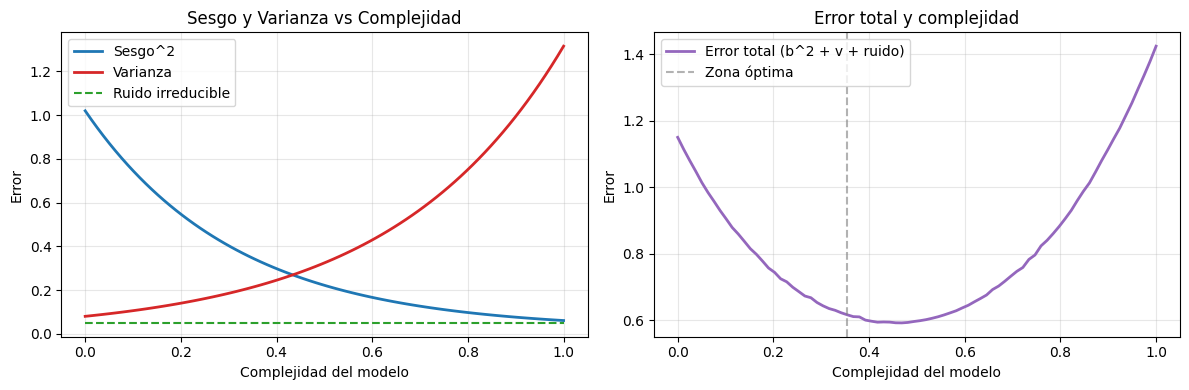

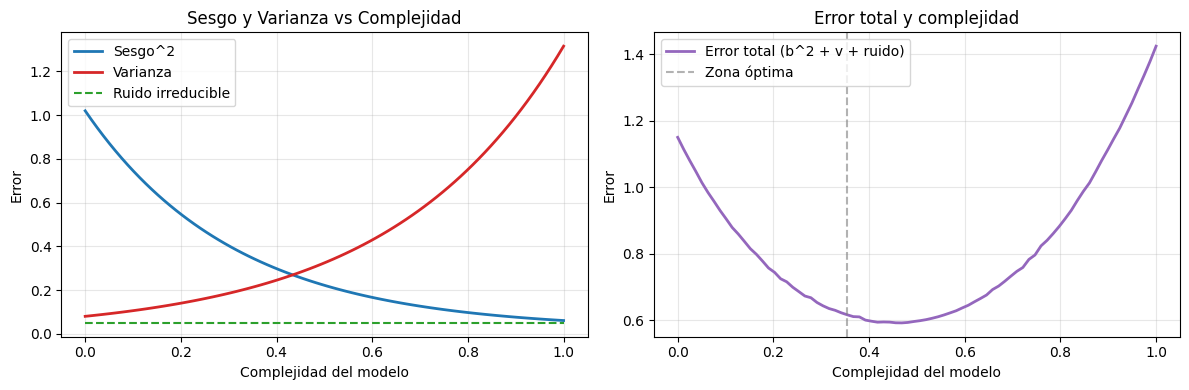

In [54]:
# Curva teórica de sesgo-varianza y error total
from modelos.bias_variance_utils import plot_bias_variance_tradeoff
plot_bias_variance_tradeoff()